In [31]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense , Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import BertTokenizer , BertForSequenceClassification , TrainingArguments , Trainer
import torch
from torch.utils.data import Dataset
import numpy as np
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [32]:
url = "https://raw.githubusercontent.com/laxmimerit/All-CSV-ML-Data-Files-Download/master/IMDB-Dataset.csv"
df = pd.read_csv(url)

df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [33]:
df.shape

(50000, 2)

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [35]:
df.isna().sum()

,0
review,0
sentiment,0


In [36]:
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [37]:
df = df.drop_duplicates()

In [38]:
df['review']=df['review'].str.lower()
df['review'].head()

,review
0,one of the other reviewers has mentioned that ...
1,a wonderful little production. <br /><br />the...
2,i thought this was a wonderful way to spend ti...
3,basically there's a family where a little boy ...
4,"petter mattei's ""love in the time of money"" is..."


In [39]:
def clean_text (text) :
  text = re.sub(r'[^a-zA-Z]', ' ', text)
  return text
df['review']=df['review'].apply(clean_text)
df['review'].head()

,review
0,one of the other reviewers has mentioned that ...
1,a wonderful little production br br the...
2,i thought this was a wonderful way to spend ti...
3,basically there s a family where a little boy ...
4,petter mattei s love in the time of money is...


In [40]:
df['review'] = df['review'].str.split().str.join(' ')

In [41]:
nltk.download('stopwords')
stopwords = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [42]:
stopwords.discard('no')
stopwords.discard('not')
stopwords.discard('never')

In [43]:
def remove_stopwords (text):
  words = text.split()
  words = [word for word in words if word not in stopwords]
  return ' '.join(words)

In [44]:
df['review']=df['review'].apply(remove_stopwords)
df['review'].head()

,review
0,one reviewers mentioned watching oz episode ho...
1,wonderful little production br br filming tech...
2,thought wonderful way spend time hot summer we...
3,basically family little boy jake thinks zombie...
4,petter mattei love time money visually stunnin...


In [45]:
vectorizer = TfidfVectorizer(max_features=5000,ngram_range=(1,2))
x = vectorizer.fit_transform(df['review']).toarray()
y = df['sentiment']
x.shape

(49582, 5000)

In [46]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [47]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [48]:
y_pred = model.predict(x_test)
acc_logistic = accuracy_score(y_test,y_pred)
print("Accuracy",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy 0.8904910759302208
              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      4939
    positive       0.88      0.90      0.89      4978

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917



In [49]:
model_nb = MultinomialNB()
model_nb.fit(x_train,y_train)

MultinomialNB()

In [50]:
y_pred_nb = model_nb.predict(x_test)
acc_nb = accuracy_score(y_test,y_pred_nb)
print("Accuracy",accuracy_score(y_test,y_pred_nb))
print(classification_report(y_test,y_pred_nb))

Accuracy 0.8591307855198145
              precision    recall  f1-score   support

    negative       0.87      0.84      0.86      4939
    positive       0.85      0.88      0.86      4978

    accuracy                           0.86      9917
   macro avg       0.86      0.86      0.86      9917
weighted avg       0.86      0.86      0.86      9917



In [51]:
print("Logistic:", accuracy_score(y_test, y_pred))
print("Naive Bayes:", accuracy_score(y_test, y_pred_nb))

Logistic: 0.8904910759302208
Naive Bayes: 0.8591307855198145


In [52]:
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(df['review'])
x_seq = tokenizer.texts_to_sequences(df['review'])

In [53]:
max_len = 100
x_pad = pad_sequences(x_seq,maxlen=max_len,padding='post')

In [54]:
y = df['sentiment'].map({'positive':1,'negative':0}).values

In [55]:
x_train,x_test,y_train,y_test = train_test_split(x_pad,y,test_size=0.2,random_state=42)

In [56]:
model = Sequential()

model.add(Embedding(input_dim=10000,output_dim=128,input_length=max_len))

model.add(LSTM(32,return_sequences=True))
model.add(Dropout(0.5))

model.add(LSTM(16))
model.add(Dropout(0.2))

model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [57]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [58]:
early_stop = EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)

In [59]:
history = model.fit(x_train,y_train,epochs=10,batch_size=32,validation_data=(x_test,y_test),callbacks=[early_stop])

Epoch 1/10
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.6813 - loss: 0.5804 - val_accuracy: 0.6183 - val_loss: 0.6336
Epoch 2/10
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.8160 - loss: 0.4313 - val_accuracy: 0.8438 - val_loss: 0.3674
Epoch 3/10
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.8833 - loss: 0.3120 - val_accuracy: 0.8680 - val_loss: 0.3290
Epoch 4/10
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.9175 - loss: 0.2313 - val_accuracy: 0.8689 - val_loss: 0.3242
Epoch 5/10
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.9414 - loss: 0.1771 - val_accuracy: 0.8716 - val_loss: 0.3604
Epoch 6/10
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.9579 - loss: 0.1351 - val_accuracy: 0.8643 - val_loss: 0.3913
Epoch 7/10
1240/1240 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.9688 - loss: 0.1059 - val_accuracy: 0.8683 - val_loss: 0.4402


In [60]:
loss, acc = model.evaluate(x_test, y_test)
acc_lstm = acc
print("Test Accuracy:", acc)

310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8689 - loss: 0.3242
Test Accuracy: 0.8689119815826416


In [61]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [62]:
texts = df['review'].tolist()
labels = df['sentiment'].map({'positive':1, 'negative':0}).tolist()

In [63]:
encodings = tokenizer(
    texts,
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors='pt'
)

In [64]:
class IMDBDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

In [65]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=128)

In [66]:
train_dataset = IMDBDataset(train_encodings, train_labels)
test_dataset = IMDBDataset(test_encodings, test_labels)

In [67]:
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [68]:
output_dir='/content/drive/MyDrive/bert_model'

In [69]:
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/bert_model",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    learning_rate=2e-5,
    warmup_steps=500,
    lr_scheduler_type="linear",
    weight_decay=0.01,
    save_steps=500,
    save_total_limit=2,
    logging_steps=100,
    do_eval=True
)

In [70]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, predictions)
    }

In [71]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [85]:
trainer.train()

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Step,Training Loss


TypeError: expected str, bytes or os.PathLike object, not TrainOutput

In [73]:
trainer.save_model("/content/drive/MyDrive/bert_model/final_model")
tokenizer.save_pretrained("/content/drive/MyDrive/bert_model/final_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/bert_model/final_model/tokenizer_config.json',
 '/content/drive/MyDrive/bert_model/final_model/tokenizer.json')

In [81]:
results = trainer.evaluate()
print(results)

{'eval_loss': 0.5066481232643127, 'eval_accuracy': 0.9008772814359182, 'eval_runtime': 76.1773, 'eval_samples_per_second': 130.183, 'eval_steps_per_second': 16.278, 'epoch': 3.0}


In [82]:
acc_bert = results['eval_accuracy']

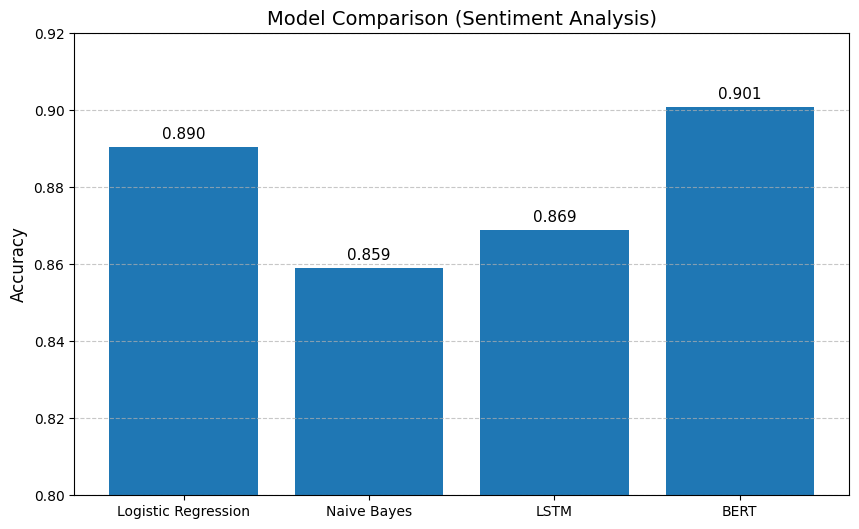

In [83]:
models = ['Logistic Regression', 'Naive Bayes', 'LSTM', 'BERT']
scores = [acc_logistic, acc_nb, acc_lstm, acc_bert]
plt.figure(figsize=(10,6))

bars = plt.bar(models, scores)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002,
             f"{yval:.3f}", ha='center', fontsize=11)

plt.ylim(0.8, 0.92)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Model Comparison (Sentiment Analysis)", fontsize=14)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()
